## Example 2b:
Example workflow that trains a CNN to predict the amplitude and phase aberration coefficients from a z-stack, using synthetic examples generated from the forwards model on-the-fly as training data.

Using the `ZstackSolver_Heteroscedastic` model, we can also fit the single-variate uncertainty of each amplitude/phase coefficient, rather than just the most likely value.

In [1]:
import logging
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.utilities.visualization import (
    plot_stack,
    plot_coefficient_uncertainties,
)
from cynosure.zstack_decoding import ZstackSolver_Heteroscedastic

#### Simulation setup

In [4]:
train_cfg = get_default_training_config(generator_chunk=16)
sim_cfg = get_default_simulation_config(object_pixel_size=0.1)
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config(
    allowed_nm=(
        (0, 0),
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -1), (3, 1),
        (4, 0),
    )
)
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
dz = 0.4  # um, physical objective z-step
num_z = 7  # number of z-slices to fit, ~centered around the focal plane
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
z = torch.arange(-(num_z//2), num_z//2 + 1).float() * dz

#### Solver setup and training

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_Heteroscedastic(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    z_objective=z,
    object_distribution=object_distrib,
    noise_cfg=noise_cfg,
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)
solver = solver.eval()

Sanity Checking: |                                                           | 0/? [00:00<?, ?it/s]

Training: |                                                                  | 0/? [00:00<?, ?it/s]

#### Sanity checking the results

As in example 2a, we should be able to generate ground truth images + aberration labels, re-predict the aberrations from those images,
and use those predicted aberrations to forwards-simulate a set of predicted images that match the original images.

In [9]:
batch_size = 4
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)
    pred_images = solver.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

Arbitrarily choose the `batch_index=0` element to compare.

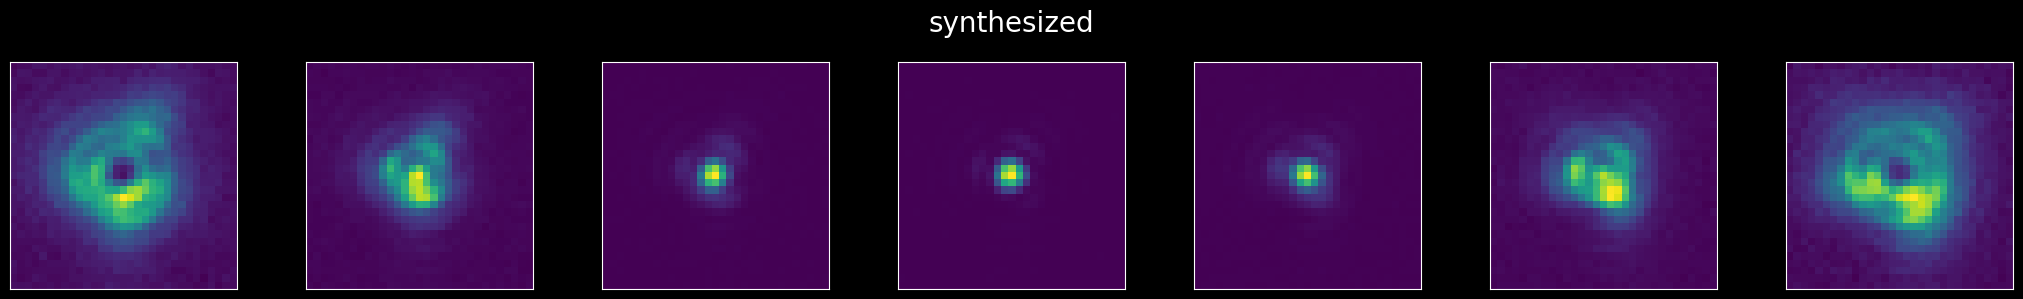

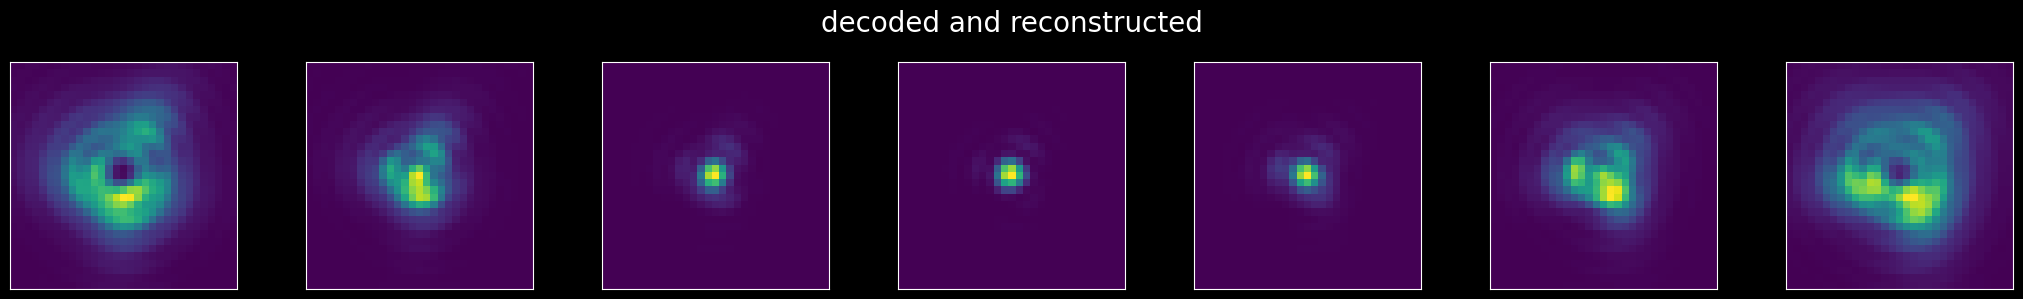

In [10]:
bidx = 0

fig1 = plot_stack(images.numpy(force=True)[bidx])
fig1.suptitle("synthesized", size=20)
fig1.tight_layout()

fig2 = plot_stack(pred_images.numpy(force=True)[bidx])
fig2.suptitle("decoded and reconstructed", size=20)
fig2.tight_layout()


#### Visualizing the predicted variances

In [11]:
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.create_examples(256)
    dist = solver.predict_distribution(images)

In [12]:
kept_labels = solver.nonpiston_labels
sigmas = dist.stddev
prior_sigmas = solver.gather_nonpiston(solver.target_scales)

For each aberration coefficient, plot the predicted uncertainty alongside the prior uncertainty.
The gap between them is the degree to which the model believes it's been able to reduce the uncertainty.

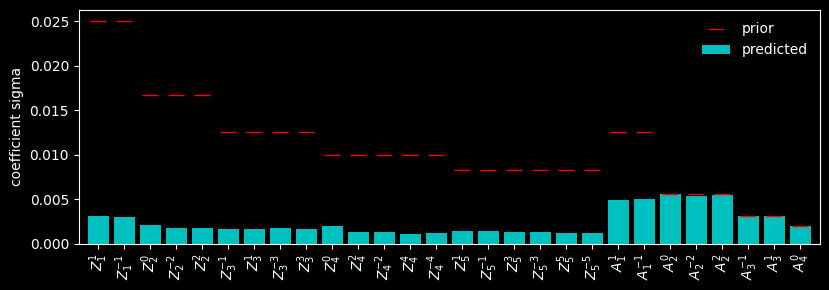

In [13]:
fig3 = plot_coefficient_uncertainties(
    sigmas.mean(0).numpy(force=True),
    prior_sigmas.numpy(force=True),
    kept_labels,
)

The `z_std` metric should be near 1 if the sigmas are calibrated:

In [14]:
print(trainer.logged_metrics["val/z_std"])

tensor(0.9934)
